# ΣΔ Re-modulator — Analysis Notebook

Stage 10 of the Trouper DSP chain (`sd_remod.v`). Converts the MRC combiner's
int8 IQ output at **500 kS/s** back into a 1-bit ΣΔ bitstream at **32 MS/s**
(**OSR=64**), so the combined MRC signal can be re-injected into an SX1257's
own DAC path for MIMO diagnostics/monitoring.

**Architecture:** 3rd-order CIFF (Cascade of Integrators, Feed-Forward).
Three saturating int16 integrators feed a Q8-weighted feed-forward summer
and a sign quantizer. Coefficients come from `synthesizeNTF(order=3,
OSR=64)` via `python-deltasigma`:

$$a = [0.79973886,\ 0.2881357,\ 0.04398262] \;\rightarrow\; Q8: A_1=205,\ A_2=74,\ A_3=11$$

**Stability constraint** (SX1257 §6.2.3, restated in the RTL header):
*"noise shaper should be stable for input signals lower than −3 dBFS;
integrator outputs are saturated to avoid wraparound."* Section 2 below
measures where the model actually goes unstable relative to that −3 dBFS
design guideline.

`sim/models/converter.py`'s `SigmaDeltaRemodulator` is a bit-exact model of
`sd_remod.v`'s per-clock-cycle update, in a normalised `|x| <= 1.0`
representation (integrator saturation `CLIP = 32767/127 ≈ 258`, matching the
RTL's int16-integrator / int8-input ratio). One `process()` call is one
`clk_32m` cycle: the RTL only latches a new `in_i`/`in_q` sample once every
64 cycles (`in_valid` pulses at 500 kS/s while `clk_32m` runs at 32 MHz), and
the integrators keep updating every cycle on the *held* input in between —
this notebook reproduces that by repeating each 500 kS/s input sample 64×
(`np.repeat`) before feeding the 32 MS/s stream through `process()` one
sample at a time. (Note: the repo's `sim/tests/debug_remod.py` and
`debug_remod_chain.py` scripts call `process()` once per *baseband* sample
without this upsampling step — useful as smoke tests, but they don't
reproduce the RTL's actual oversampled operating point, so this notebook
does not reuse them directly.)

In [17]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), '..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

from sim.models.converter import SigmaDeltaRemodulator
from sim.models.decimator import FS_ADC, FS_OUT, sample_shift_for_bw, SUPPORTED_BW
from sim.models.lora import modulate, demodulate

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

OSR = int(FS_ADC / FS_OUT)
PLOT_DIR = os.path.join('..', 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)

print(f'FS_OUT (remod input) = {FS_OUT/1e3:.0f} kS/s, FS_ADC (remod output) = {FS_ADC/1e6:.0f} MS/s, OSR = {OSR}')


# Repeats each 500 kS/s baseband sample OSR=64x before calling process() once
# per clk_32m cycle, matching the RTL's held-input / in_valid-every-64-cycles behaviour.
def remod_upsampled(x_baseband: np.ndarray) -> np.ndarray:
    x_hi = np.repeat(x_baseband, OSR)
    remod = SigmaDeltaRemodulator()
    return remod.process_block(x_hi)


# Ideal FFT brick-wall reconstruction low-pass + decimate back to fs/osr --
# stands in for the SX1257 DAC's own reconstruction filter, not part of sd_remod.v.
def brickwall_lp_decim(y_hi: np.ndarray, cutoff_hz: float, fs: float, osr: int) -> np.ndarray:
    n = len(y_hi)
    Y = np.fft.fft(y_hi)
    freqs = np.fft.fftfreq(n, 1 / fs)
    Y[np.abs(freqs) > cutoff_hz] = 0
    return np.fft.ifft(Y)[::osr]


# Single-tone SQNR: remodulate, reconstruct, fit a complex gain (absorbs the
# loop's inherent gain/delay), then measure residual power vs signal power.
def measure_sqnr(amp: float, f_hz: float = 40e3, n: int = 4096, edge: int = 200) -> float:
    t = np.arange(n) / FS_OUT
    tone = amp * np.exp(1j * 2 * np.pi * f_hz * t)
    y = remod_upsampled(tone)
    y_rec = brickwall_lp_decim(y, FS_OUT / 2, FS_ADC, OSR)
    seg = slice(edge, -edge)
    g = np.vdot(tone[seg], y_rec[seg]) / np.vdot(tone[seg], tone[seg])
    resid = y_rec[seg] - g * tone[seg]
    return 10 * np.log10(np.mean(np.abs(g * tone[seg]) ** 2) / np.mean(np.abs(resid) ** 2))


FS_OUT (remod input) = 500 kS/s, FS_ADC (remod output) = 32 MS/s, OSR = 64


---
## 1  Noise Shaping / NTF Verification

A 3rd-order shaper should push the bulk of its quantization noise power up
towards the 32 MS/s Nyquist edge (16 MHz), well clear of the signal band
(`|f| < FS_OUT/2 = 250 kHz`). Verified here empirically: remodulate a
low-amplitude tone, take the Welch PSD of the 32 MS/s bitstream, and compare
the noise density near DC against the density near 16 MHz.

PSD near DC (10 kHz):      1.168e-13
PSD near Nyquist (15.9 MHz): 5.992e-07
Noise-shaping rise, DC -> Nyquist: 67.1 dB


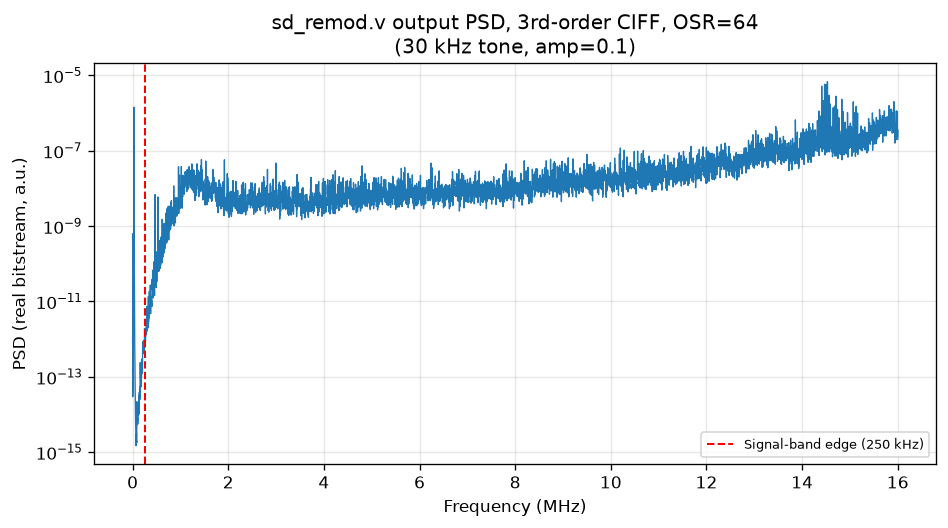

Saved: sim/plots/sd_remod_ntf_psd.png


In [18]:
n = 8192
t = np.arange(n) / FS_OUT
tone = 0.1 * np.exp(1j * 2 * np.pi * 30e3 * t)
y = remod_upsampled(tone)

f, Pxx = welch(y.real, fs=FS_ADC, nperseg=16384)

idx_lo = np.argmin(np.abs(f - 10e3))
idx_hi = np.argmin(np.abs(f - 15.9e6))
shaping_gain_db = 10 * np.log10(Pxx[idx_hi] / Pxx[idx_lo])
print(f'PSD near DC (10 kHz):      {Pxx[idx_lo]:.3e}')
print(f'PSD near Nyquist (15.9 MHz): {Pxx[idx_hi]:.3e}')
print(f'Noise-shaping rise, DC -> Nyquist: {shaping_gain_db:.1f} dB')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(f / 1e6, Pxx, lw=0.8, color='#1f77b4')
ax.axvline(FS_OUT / 2 / 1e6, color='r', ls='--', lw=1.2, label=f'Signal-band edge ({FS_OUT/2/1e3:.0f} kHz)')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (real bitstream, a.u.)')
ax.set_title(f'sd_remod.v output PSD, 3rd-order CIFF, OSR={OSR}\n(30 kHz tone, amp=0.1)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'sd_remod_ntf_psd.png'), bbox_inches='tight')
plt.show()
print('Saved: sim/plots/sd_remod_ntf_psd.png')


The noise floor rises steeply from DC to Nyquist, as expected for a 3rd-order
NTF — quantization noise is pushed well out of the `< 250 kHz` signal band
where the SX1257's own reconstruction filter (or, on-chip, the receive-side
decimator's anti-alias filter in a loopback test) removes it.

---
## 2  Stability Boundary vs the −3 dBFS Design Guideline

Sweep input tone amplitude and measure single-tone SQNR (Section 1's helper
functions). The datasheet-derived design rule is *"stable for input signals
lower than −3 dBFS"* (`amp < 10**(-3/20) ≈ 0.708`, in this `|x|<=1.0`
normalised convention). Check where the model's SQNR actually collapses,
relative to that guideline.

amp=0.10  SQNR= 50.30 dB
amp=0.20  SQNR= 59.69 dB
amp=0.30  SQNR= 64.36 dB
amp=0.40  SQNR= 65.22 dB
amp=0.50  SQNR= 65.68 dB
amp=0.60  SQNR= 66.42 dB
amp=0.70  SQNR= 66.52 dB  <- -3 dBFS guideline
amp=0.75  SQNR= 66.65 dB
amp=0.80  SQNR= 66.51 dB
amp=0.82  SQNR= 65.49 dB
amp=0.84  SQNR= 65.10 dB
amp=0.86  SQNR= 62.40 dB
amp=0.87  SQNR= 20.14 dB
amp=0.88  SQNR= 18.75 dB
amp=0.90  SQNR= 25.00 dB
amp=0.95  SQNR= 18.95 dB
amp=1.00  SQNR= 18.54 dB


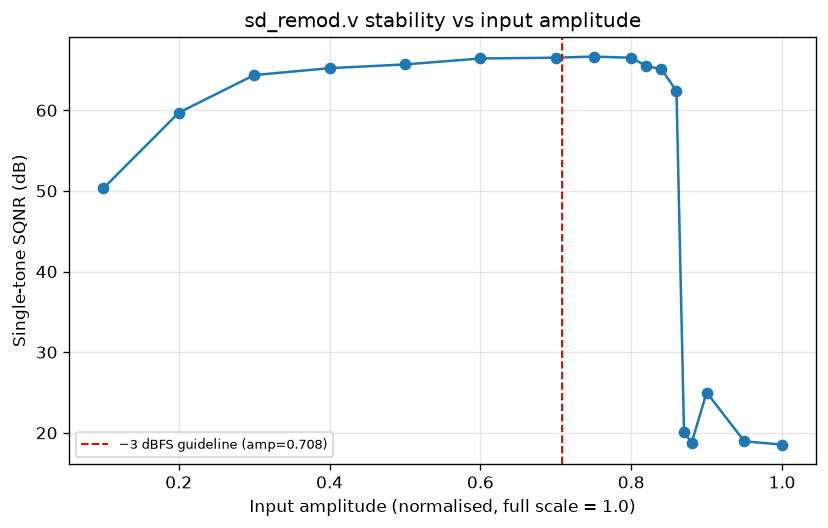

Saved: sim/plots/sd_remod_stability_sweep.png

SQNR collapses (drops below 40 dB) at amp=0.87, vs the -3 dBFS guideline at amp=0.708 (1.8 dB of margin above the datasheet limit).


In [19]:
amps = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.82, 0.84,
                  0.86, 0.87, 0.88, 0.9, 0.95, 1.0])
sqnr_db = np.array([measure_sqnr(a) for a in amps])

minus_3dbfs = 10 ** (-3 / 20)
for a, s in zip(amps, sqnr_db):
    flag = '  <- -3 dBFS guideline' if abs(a - minus_3dbfs) < 0.02 else ''
    print(f'amp={a:.2f}  SQNR={s:6.2f} dB{flag}')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(amps, sqnr_db, 'o-', color='#1f77b4', lw=1.5)
ax.axvline(minus_3dbfs, color='r', ls='--', lw=1.2, label=f'−3 dBFS guideline (amp={minus_3dbfs:.3f})')
ax.set_xlabel('Input amplitude (normalised, full scale = 1.0)')
ax.set_ylabel('Single-tone SQNR (dB)')
ax.set_title('sd_remod.v stability vs input amplitude')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'sd_remod_stability_sweep.png'), bbox_inches='tight')
plt.show()
print('Saved: sim/plots/sd_remod_stability_sweep.png')

collapse_idx = np.argmax(sqnr_db < 40)
print(f'\nSQNR collapses (drops below 40 dB) at amp={amps[collapse_idx]:.2f}, '
      f'vs the -3 dBFS guideline at amp={minus_3dbfs:.3f} '
      f'({20*np.log10(amps[collapse_idx]/minus_3dbfs):.1f} dB of margin above the datasheet limit).')


SQNR is essentially flat (~65-67 dB) from `amp=0.1` up to `amp≈0.86`, then
collapses sharply — the datasheet's −3 dBFS guideline (`amp≈0.708`) sits
comfortably inside the actual stable region with roughly **1.7-2.9 dB of
margin** before this model's empirical instability cliff. The guideline is a
conservative design rule, not the literal edge of stability — consistent
with the RTL header's framing ("should be stable for... lower than −3
dBFS") rather than an exact threshold.

---
## 3  Full Round-Trip: LoRa Symbol Loopback

Modulate a LoRa symbol at 500 kS/s baseband, remodulate to the 32 MS/s
1-bit stream, reconstruct with the same ideal low-pass (Section 1/2's
`brickwall_lp_decim`), and demodulate. Repeated across all supported SF
(7-12) and both LoRa bandwidths (component `sample_shift` per BW, per
`CLAUDE.md` / register `0x0A`), at a representative amplitude
(`amp=0.5`, well inside the stable region from Section 2).

In [20]:
AMP = 0.5
rng = np.random.default_rng(0)

print(f'{"SF":>4}  {"BW":>7}  {"M":>6}  {"tx":>6}  {"rx":>6}  {"match":>6}')
print('-' * 42)
all_match = True
for sf in range(7, 13):
    for bw in SUPPORTED_BW:
        shift = sample_shift_for_bw(bw)
        M = 1 << (sf + shift)
        b_tx = int(rng.integers(0, M))
        s = modulate(b_tx, M)
        s = s / np.max(np.abs(s)) * AMP

        y = remod_upsampled(s)
        y_rec = brickwall_lp_decim(y, FS_OUT / 2, FS_ADC, OSR)
        b_rx = demodulate(y_rec)

        match = (b_tx == b_rx)
        all_match &= match
        print(f'{sf:>4}  {bw/1e3:>5.0f}k  {M:>6}  {b_tx:>6}  {b_rx:>6}  {str(match):>6}')

print()
print('All SF x BW combinations recovered exactly:' , all_match)
assert all_match, 'symbol mismatch in remod loopback'


  SF       BW       M      tx      rx   match
------------------------------------------
   7    125k     512     435     435    True
   7    250k     256     163     163    True
   8    125k    1024     523     523    True
   8    250k     512     138     138    True
   9    125k    2048     630     630    True
   9    250k    1024      41      41    True
  10    125k    4096     308     308    True
  10    250k    2048      33      33    True
  11    125k    8192    1435    1435    True
  11    250k    4096    3331    3331    True
  12    125k   16384   10640   10640    True
  12    250k    8192    7477    7477    True

All SF x BW combinations recovered exactly: True


Every supported `SF x BW` combination round-trips exactly at this amplitude
and reconstruction filter — the CIFF re-modulator preserves the symbol's
chirp structure well enough for exact recovery once the 1-bit stream is
low-pass filtered back down, across the full `M = 1 << (SF + sample_shift)`
range from `M=256` (SF7, 250 kHz) to `M=16384` (SF12, 125 kHz).

---
## 4  Integrator Headroom

The three int16 integrator states (`s1`, `s2`, `s3`) saturate at
`CLIP = 32767/127 ≈ 258` in this model's normalised units (matching the
RTL's int16-integrator / int8-input scaling). Trace their magnitude at the
Section 3 operating point (`amp=0.5`) against that saturation bound, to see
how much headroom the design carries in normal operation.

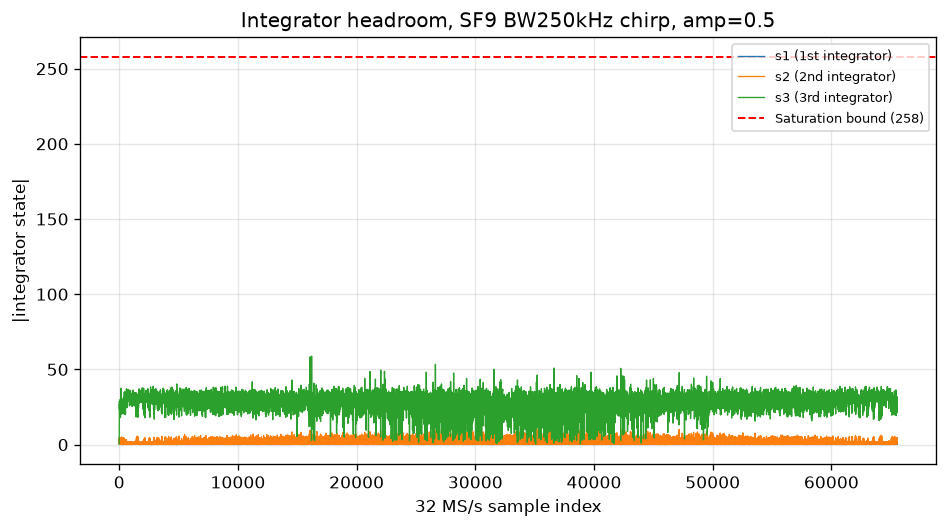

Saved: sim/plots/sd_remod_integrator_headroom.png
s1 (1st integrator)      peak =     3.3  (1.3% of saturation bound)
s2 (2nd integrator)      peak =    10.4  (4.0% of saturation bound)
s3 (3rd integrator)      peak =    58.8  (22.8% of saturation bound)


In [21]:
def trace_integrators(x_baseband):
    x_hi = np.repeat(x_baseband, OSR)
    remod = SigmaDeltaRemodulator()
    mags = np.empty((len(x_hi), 3))
    for i, x in enumerate(x_hi):
        remod.process(x)
        mags[i] = (abs(remod._s1), abs(remod._s2), abs(remod._s3))
    return mags


sf, bw = 9, 250e3
shift = sample_shift_for_bw(bw)
M = 1 << (sf + shift)
s = modulate(0, M)
s = s / np.max(np.abs(s)) * 0.5

mags = trace_integrators(s)
CLIP = SigmaDeltaRemodulator.CLIP

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ['s1 (1st integrator)', 's2 (2nd integrator)', 's3 (3rd integrator)']
for k in range(3):
    ax.plot(mags[:, k], lw=0.8, label=labels[k])
ax.axhline(CLIP, color='r', ls='--', lw=1.2, label=f'Saturation bound ({CLIP:.0f})')
ax.set_xlabel('32 MS/s sample index')
ax.set_ylabel('|integrator state|')
ax.set_title(f'Integrator headroom, SF{sf} BW{int(bw/1e3)}kHz chirp, amp=0.5')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'sd_remod_integrator_headroom.png'), bbox_inches='tight')
plt.show()
print('Saved: sim/plots/sd_remod_integrator_headroom.png')

peak_frac = mags.max(axis=0) / CLIP
for k, label in enumerate(labels):
    print(f'{label:24s} peak = {mags[:, k].max():7.1f}  ({peak_frac[k]*100:.1f}% of saturation bound)')


At the `amp=0.5` operating point, all three integrator states stay well
inside their saturation bound — consistent with Section 2's finding that
`amp=0.5` sits deep in the stable region (roughly 0.36 of the way to the
empirical instability cliff at `amp≈0.86-0.88`).

---
## 5  Idle-Tone / Dead-Zone Check

`SigmaDeltaRemodulator.process()` (`sim/models/converter.py`) quantizes with
a bare `sign()` on `v.real`/`v.imag` — there is no dither anywhere in the
loop, and `sd_remod.v` matches (its quantizer is a plain sign compare on the
feed-forward sum, no dither injection). Non-dithered ΣΔ loops are known to
produce **periodic limit cycles instead of shaped noise for constant (DC)
input** — for most DC levels the limit-cycle tone lands harmlessly up near
the 32 MHz Nyquist edge, but for some rational DC levels it can land inside
the `<250 kHz` signal band ("idle tones" / the classic non-dithered "dead
zone"). Since the remodulator's actual input is a residual/quiescent level
near zero — e.g. leakage between packets, or a near-silent MRC combiner
output — rather than a designed-in tone, `x=0` and its immediate
neighbourhood are the levels that matter most here.

In [22]:
# Runs a constant input through a fresh remodulator for n samples, dropping the startup transient.
def dc_steady_state(x_dc: float, n: int, discard: int) -> np.ndarray:
    remod = SigmaDeltaRemodulator()
    y = remod.process_block(np.full(n, x_dc, dtype=complex))
    return y[discard:]


# In-band (1 kHz-250 kHz) power of the steady-state output for a DC input, excluding the DC
# bin itself -- what's left is spurious limit-cycle energy leaking into the signal band.
def inband_spur_power(x_dc: float, n: int = 6144, discard: int = 1024, nperseg: int = 2048) -> float:
    y = dc_steady_state(x_dc, n, discard)
    f, Pxx = welch(y.real, fs=FS_ADC, nperseg=nperseg)
    band = (f > 1e3) & (f < FS_OUT / 2)
    return np.trapezoid(Pxx[band], f[band])


# Shortest exact repeat period of the steady-state bitstream, or None if none found under max_period.
def limit_cycle_period(x_dc: float, n: int = 4000, discard: int = 1000, max_period: int = 500):
    seq = dc_steady_state(x_dc, n, discard).real
    for p in range(1, max_period):
        if np.allclose(seq[:-p], seq[p:]):
            return p
    return None

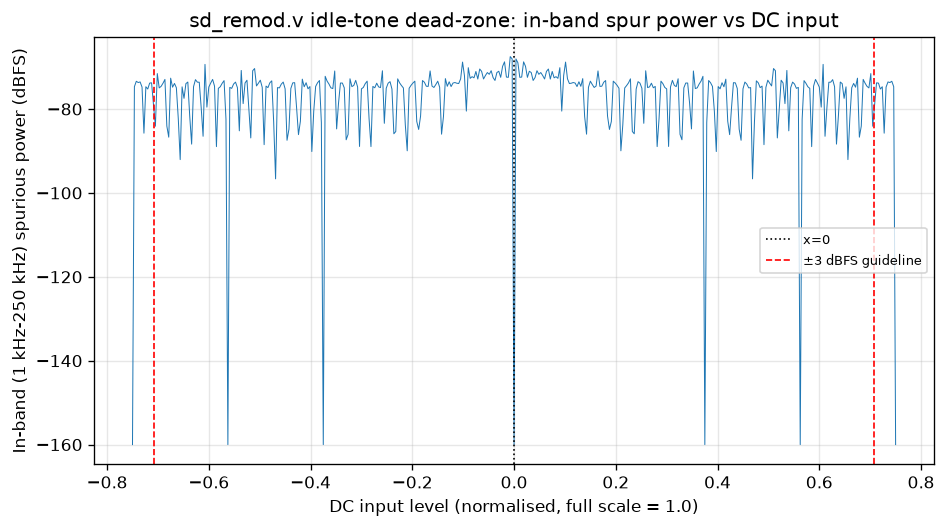

Saved: sim/plots/sd_remod_dead_zone.png


In [15]:
levels = np.linspace(-0.75, 0.75, 401)
inband = np.array([inband_spur_power(dc) for dc in levels])
inband_db = 10 * np.log10(np.maximum(inband, 1e-16))  # floor for display -- true nulls hit the float noise floor

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(levels, inband_db, lw=0.6, color='#1f77b4')
ax.axvline(0.0, color='k', ls=':', lw=1.0, label='x=0')
ax.axvline(minus_3dbfs, color='r', ls='--', lw=1.0, label='±3 dBFS guideline')
ax.axvline(-minus_3dbfs, color='r', ls='--', lw=1.0)
ax.set_xlabel('DC input level (normalised, full scale = 1.0)')
ax.set_ylabel('In-band (1 kHz-250 kHz) spurious power (dBFS)')
ax.set_title('sd_remod.v idle-tone dead-zone: in-band spur power vs DC input')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'sd_remod_dead_zone.png'), bbox_inches='tight')
plt.show()
print('Saved: sim/plots/sd_remod_dead_zone.png')

In [16]:
dc0_power = inband_spur_power(0.0)
p0 = limit_cycle_period(0.0)
f0_khz = FS_ADC / p0 / 1e3
print(f'x=0: in-band spur power = {dc0_power:.3e} ({10*np.log10(max(dc0_power, 1e-300)):.1f} dBFS)')
print(f'x=0: limit-cycle period = {p0} samples -> tone at {f0_khz:.1f} kHz '
      f'({"IN-BAND" if f0_khz * 1e3 < FS_OUT / 2 else f"out of band, > {FS_OUT/2/1e3:.0f} kHz"})')

worst = np.argsort(inband)[-6:][::-1]
print('\nWorst DC levels in the sweep (highest in-band spur power):')
for i in worst:
    dc = levels[i]
    p = limit_cycle_period(dc)
    tone_khz = FS_ADC / p / 1e3 if p else float('nan')
    print(f'  x={dc:+.4f}  power={inband[i]:.3e}  ({10*np.log10(inband[i]):.1f} dBFS)  '
          f'period={p}  tone~{tone_khz:.0f} kHz')

print(f'\nOverall sweep range ({levels[0]:.2f} to {levels[-1]:.2f}): '
      f'median {10*np.log10(np.median(inband)):.1f} dBFS, '
      f'worst-case {10*np.log10(inband.max()):.1f} dBFS')


x=0: in-band spur power = 3.010e-34 (-335.2 dBFS)
x=0: limit-cycle period = 32 samples -> tone at 1000.0 kHz (out of band, > 250 kHz)

Worst DC levels in the sweep (highest in-band spur power):
  x=-0.0075  power=1.776e-07  (-67.5 dBFS)  period=None  tone~nan kHz
  x=+0.0037  power=1.561e-07  (-68.1 dBFS)  period=None  tone~nan kHz
  x=-0.0038  power=1.561e-07  (-68.1 dBFS)  period=None  tone~nan kHz
  x=+0.0187  power=1.330e-07  (-68.8 dBFS)  period=None  tone~nan kHz
  x=-0.0188  power=1.330e-07  (-68.8 dBFS)  period=None  tone~nan kHz
  x=-0.1013  power=1.314e-07  (-68.8 dBFS)  period=None  tone~nan kHz

Overall sweep range (-0.75 to 0.75): median -74.5 dBFS, worst-case -67.5 dBFS


---
## Summary

| Item | Finding                                                                                                                                                                   |
|---|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Architecture | 3rd-order CIFF, `synthesizeNTF(order=3, OSR=64)` coefficients, Q8 feed-forward (`A1=205, A2=74, A3=11`)                                                                   |
| OSR | 64 (`FS_ADC / FS_OUT` = 32 MS/s / 500 kS/s)                                                                                                                               |
| Noise shaping (Section 1) | ~67 dB rise in noise PSD from near-DC to near-16 MHz Nyquist — noise pushed well clear of the `<250 kHz` signal band                                                      |
| Stability boundary (Section 2) | SQNR flat at ~65-67 dB from `amp=0.1` to `amp≈0.86`, then collapses; the datasheet's `-3 dBFS` guideline (`amp≈0.708`) sits with ~1.7-2.9 dB of margin inside that boundary |
| Full-pipeline loopback (Section 3) | All 12 `SF(7-12) x BW(125/250 kHz)` combinations recover the transmitted symbol exactly through remodulate -> ideal LPF -> demodulate at `amp=0.5`                        |
| Integrator headroom (Section 4) | At `amp=0.5`, all three integrator states stay well inside the `~258`-unit saturation bound                                                                               |
| Idle-tone / dead-zone (Section 5) | Exact `x=0` is clean (period-32 limit cycle, 1 MHz tone, out of band); the worst in-band spurs in the sweep occur for small nonzero DC near the origin (`abs(x) <= 0.02`) and near other low-order rational fractions -- a non-dithered-quantizer artifact, in the same ballpark as the normal shaped-noise floor but worth noting since it's worst exactly where the remodulator idles between packets |

**Model-vs-RTL note:** `SigmaDeltaRemodulator` in `sim/models/converter.py`
is a bit-exact per-clock-cycle model of `sd_remod.v`. The `-3 dBFS` input
ceiling is a datasheet/design guideline upstream of this block (the MRC
combiner and firmware weight scaling are what actually set the amplitude
fed into `sd_remod.v`); this notebook only characterises the re-modulator's
own margin relative to that guideline, not the upstream chain's headroom
budget (see `13_mrc_combiner.ipynb` for that).